## **Road Pulse:** Random Forest Modeling

### Library Imports

In [31]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [2]:
data = pd.read_excel('../data/processed/accident_processed_srb.xlsx')

### **Data into train and test sets**

In [3]:
X = data.drop(columns='accident_type')
y = data['accident_type']

In [4]:
print(y.value_counts())
print(y.value_counts(normalize=True))

accident_type
0    122545
1     82807
Name: count, dtype: int64
accident_type
0    0.596756
1    0.403244
Name: proportion, dtype: float64


Taget percentage in processed data:
- **"0"** (*Material*): **60%** 
- **"1"** (*Injured or Dead*): **40%**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### **Random Forest Model**

#### **Iteration 1:**

##### Training

In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

In [7]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##### Evaluation

In [8]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Without dead/injured', 'With dead/injured']))

                      precision    recall  f1-score   support

Without dead/injured       0.73      0.79      0.76     24509
   With dead/injured       0.64      0.57      0.61     16562

            accuracy                           0.70     41071
           macro avg       0.69      0.68      0.68     41071
        weighted avg       0.70      0.70      0.70     41071



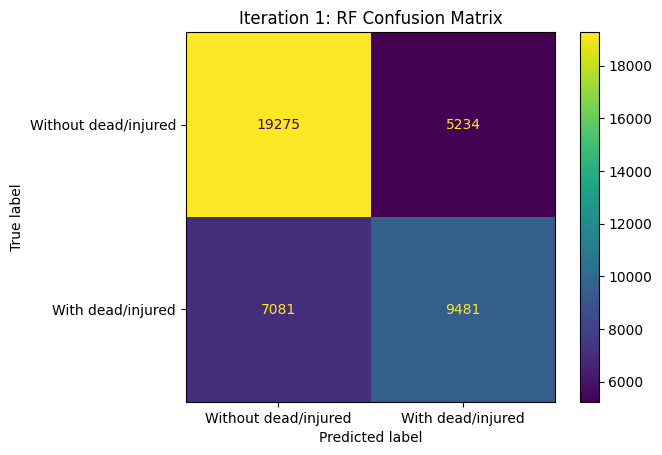

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Without dead/injured', 'With dead/injured'])
plt.title("Iteration 1: RF Confusion Matrix")
plt.show()

#### **Iteration 2:**

Lowering threshold to catch dangerous accidents, at cost of more false alarms.

##### Training and evaluation

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

y_pred_custom = (y_prob >= 0.35).astype(int)

print(classification_report(y_test, y_pred_custom,
                            target_names=['Without dead/injured', 'With dead/injured']))

                      precision    recall  f1-score   support

Without dead/injured       0.79      0.64      0.70     24509
   With dead/injured       0.58      0.74      0.65     16562

            accuracy                           0.68     41071
           macro avg       0.68      0.69      0.68     41071
        weighted avg       0.70      0.68      0.68     41071



#### **Iteration 3:**

In [11]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

##### Training

In [12]:
model2 = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=params,
    cv=5,
    scoring='f1'
)

In [13]:
model2.fit(X_train, y_train)
print(model2.best_params_)

{'max_depth': 20, 'min_samples_leaf': 4, 'n_estimators': 200}


##### Evaluation

In [16]:
best_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42
)

In [17]:
best_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_prob_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= 0.50).astype(int)

In [21]:
print(classification_report(y_test, y_pred_best, 
                            target_names=['Without dead/injured', 'With dead/injured']))

                      precision    recall  f1-score   support

Without dead/injured       0.78      0.74      0.76     24509
   With dead/injured       0.64      0.69      0.67     16562

            accuracy                           0.72     41071
           macro avg       0.71      0.71      0.71     41071
        weighted avg       0.72      0.72      0.72     41071



##### **Initial RF model:**
```terminal
                      precision    recall  f1-score   support

Without dead/injured       0.78      0.74      0.76     24509
   With dead/injured       0.64      0.69      0.67     16562

            accuracy                           0.72     41071
           macro avg       0.71      0.71      0.71     41071
        weighted avg       0.72      0.72      0.72     41071
```

In [33]:
joblib.dump(best_model, '../models/road_pulse_RF_model_init.pkl')

['../models/road_pulse_RF_model_init.pkl']